# Strict-Full vs Strict-Pruned vs Strict CatBoost Comparison with pAUC@88

이 notebook은 `Strict-Full (초기 Strict 후보)`, `Strict-Pruned`, `Strict (최종 메인 세트)`를 같은 CatBoost 설정 위에서 3-way 비교하기 위한 notebook이다.

## 실험 목적
1. 넓은 후보 세트인 `Strict-Full`, 중간 pruning 시도인 `Strict-Pruned`, 최종 채택된 `Strict`를 한 자리에서 비교한다.
2. 기본 평가지표는 `pAUC@TPR>=0.88`로 둔다.
3. 어떤 세트가 높은 민감도 구간에서 가장 설득력 있는지 확인한다.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings('ignore')

FONT_CANDIDATES = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
]
for font_path in FONT_CANDIDATES:
    if Path(font_path).exists():
        from matplotlib import font_manager as fm
        font_name = fm.FontProperties(fname=font_path).get_name()
        mpl.rcParams['font.family'] = font_name
        break
mpl.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

base_dir = Path('/home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024')
input_dir = base_dir / 'model_inputs'
out_dir = base_dir / 'modeling' / 'final_strict_vs_strict_pruned_vs_strict_full_catboost'
out_dir.mkdir(parents=True, exist_ok=True)

PRIMARY_MIN_TPR = 0.88
SECONDARY_MIN_TPR = 0.80
PRIMARY_MAX_FPR = 1 - PRIMARY_MIN_TPR
DISPLAY_NAME = {
    'strict_full': 'Strict-Full',
    'strict_full_ablation': 'Strict-Full ablation',
    'strict_pruned': 'Strict-Pruned',
    'final_strict': 'Strict',
}
DISPLAY_COLOR = {
    'strict_full': '#d55e00',
    'strict_pruned': '#009e73',
    'final_strict': '#0072b2',
}

meta_cols = ['isic_id', 'patient_id', 'target', 'split']
random_state = 42

paths = {
    'final_strict': {
        'train': input_dir / 'isic2024_final_strict_train_input.parquet',
        'validation': input_dir / 'isic2024_final_strict_validation_input.parquet',
        'internal_test': input_dir / 'isic2024_final_strict_internal_test_input.parquet',
    },
    'strict_pruned': {
        'train': input_dir / 'isic2024_strict_pruned_train_input.parquet',
        'validation': input_dir / 'isic2024_strict_pruned_validation_input.parquet',
        'internal_test': input_dir / 'isic2024_strict_pruned_internal_test_input.parquet',
    },
    'strict_full': {
        'train': input_dir / 'isic2024_strict_train_input.parquet',
        'validation': input_dir / 'isic2024_strict_validation_input.parquet',
        'internal_test': input_dir / 'isic2024_strict_internal_test_input.parquet',
    },
}

pruned_manifest = json.loads((input_dir / 'strict_pruned_feature_manifest.json').read_text())
removed_features = pruned_manifest['strict_pruned_removed_features']

catboost_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Logloss',
    'depth': 6,
    'learning_rate': 0.05,
    'iterations': 400,
    'random_seed': random_state,
    'verbose': False,
    'auto_class_weights': 'Balanced',
}

print('primary metric = pAUC@TPR>=', PRIMARY_MIN_TPR)


primary metric = pAUC@TPR>= 0.88


## 1. 입력 세트와 Pruned 규칙 확인

### 목적
코드 셀에서는 세 입력 세트의 크기와 feature 수를 확인하고, `Strict-Pruned`에서 실제로 제거된 feature 목록을 보여줍니다.

이번 `Strict-Pruned`는 이전 CatBoost ablation 결과를 바탕으로, 제거 시 성능 개선 가능성이 보인 feature들을 정리한 세트입니다.


,regime_display,split,n_rows,n_total_columns,n_feature_columns,n_positive_rows,positive_ratio_pct
0,Strict,train,280335,55,51,270,0.096313
1,Strict,validation,65684,55,51,57,0.086779
2,Strict,internal_test,55040,55,51,66,0.119913
3,Strict-Pruned,train,280335,58,54,270,0.096313
4,Strict-Pruned,validation,65684,58,54,57,0.086779
5,Strict-Pruned,internal_test,55040,58,54,66,0.119913
6,Strict-Full,train,280335,66,62,270,0.096313
7,Strict-Full,validation,65684,66,62,57,0.086779
8,Strict-Full,internal_test,55040,66,62,66,0.119913


,strict_pruned_removed_feature
0,feat_hue_circular_gap
1,feat_diameter_symmetry_coupling
2,feat_color_to_border_ratio
3,feat_nevi_border_interaction
4,feat_symmetry_contrast_interaction
5,feat_contrast_to_color_variation
6,feat_xz_radius
7,feat_perimeter_to_long_ratio


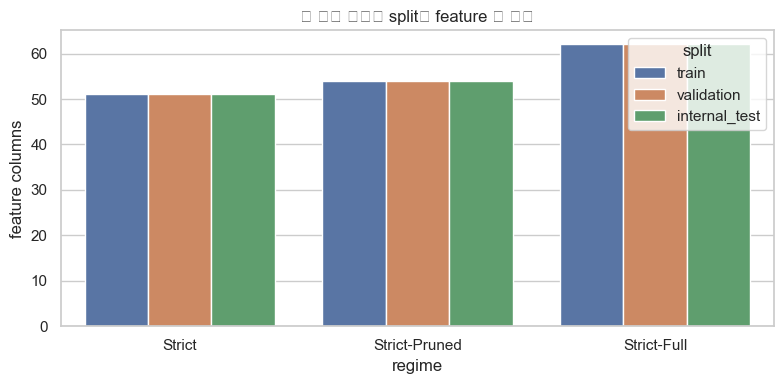

In [2]:
data = {name: {split: pd.read_parquet(path) for split, path in split_map.items()} for name, split_map in paths.items()}

rows = []
for regime_name, regime_data in data.items():
    for split, df in regime_data.items():
        feature_cols = [c for c in df.columns if c not in meta_cols]
        rows.append({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
            'split': split,
            'n_rows': len(df),
            'n_total_columns': df.shape[1],
            'n_feature_columns': len(feature_cols),
            'n_positive_rows': int(df['target'].sum()),
            'positive_ratio_pct': round(df['target'].mean() * 100, 6),
        })
summary_df = pd.DataFrame(rows)
display(summary_df[['regime_display', 'split', 'n_rows', 'n_total_columns', 'n_feature_columns', 'n_positive_rows', 'positive_ratio_pct']])
display(pd.DataFrame({'strict_pruned_removed_feature': removed_features}))

plt.figure(figsize=(8, 4))
sns.barplot(data=summary_df, x='regime_display', y='n_feature_columns', hue='split')
plt.title('세 입력 세트의 split별 feature 수 비교')
plt.xlabel('regime')
plt.ylabel('feature columns')
plt.tight_layout()
plt.show()


### 해석 포인트
1. 세 입력 세트는 행 수와 target 분포가 같고, feature 수만 달라야 합니다.
2. `Strict-Pruned`는 `Strict-Full`에서 일부 feature를 제거한 중간형 세트입니다.
3. 따라서 성능이 좋아지면, feature를 늘리는 것보다 정리하는 것이 더 중요했음을 뜻합니다.


## 2. CatBoost 공통 함수 정의

### 목적
코드 셀에서는 세 세트 모두에 동일하게 적용할 학습/평가 함수를 정의합니다.

이번 비교의 기본 평가지표는 `pAUC@TPR>=0.88`입니다.


In [3]:
def prepare_catboost_frame(df, feature_cols):
    X = df[feature_cols].copy()
    y = df['target'].astype(int).to_numpy()
    categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    for col in categorical_cols:
        X[col] = X[col].fillna('__MISSING__').astype(str)
    return X, y, categorical_cols


def p_auc_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    # pAUC@TPR>=min_tpr = ∫_0^{max_fpr} TPR(FPR) dFPR
    # where max_fpr = 1 - min_tpr.
    # For min_tpr=0.88, we only integrate the ROC curve up to FPR=0.12.
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) != 2:
        return np.nan
    v_gt = np.abs(y_true - 1)
    v_pred = np.abs(y_prob - 1)
    max_fpr = abs(1 - min_tpr)
    fpr, tpr, _ = roc_curve(v_gt, v_pred)
    stop = np.searchsorted(fpr, max_fpr, 'right')
    if stop <= 1:
        return float(max_fpr * tpr[min(stop - 1, len(tpr) - 1)])
    if stop >= len(fpr):
        return float(np.trapz(tpr, fpr))
    tpr_cut = np.append(tpr[:stop], np.interp(max_fpr, [fpr[stop - 1], fpr[stop]], [tpr[stop - 1], tpr[stop]]))
    fpr_cut = np.append(fpr[:stop], max_fpr)
    return float(np.trapz(tpr_cut, fpr_cut))


def choose_threshold_by_min_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    eligible = np.where(tpr >= min_tpr)[0]
    if len(eligible) == 0:
        best_idx = int(np.argmax(tpr - fpr))
    else:
        best_idx = eligible[np.argmin(fpr[eligible])]
    return float(thresholds[best_idx]), float(tpr[best_idx]), float(1 - fpr[best_idx])


def specificity_score(y_true, y_pred):
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return tn / max(tn + fp, 1)


def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'pauc_tpr88': float(p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)),
        'pauc_tpr80': float(p_auc_tpr(y_true, y_prob, SECONDARY_MIN_TPR)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'average_precision': float(average_precision_score(y_true, y_prob)),
        'log_loss': float(log_loss(y_true, y_prob, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, y_prob)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'specificity': float(specificity_score(y_true, y_pred)),
        'predicted_positive_rate': float(y_pred.mean()),
    }


def fit_and_score(regime_name, train_df, val_df, test_df, feature_cols):
    X_train, y_train, cat_cols = prepare_catboost_frame(train_df, feature_cols)
    X_val, y_val, _ = prepare_catboost_frame(val_df, feature_cols)
    X_test, y_test, _ = prepare_catboost_frame(test_df, feature_cols)

    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, cat_features=cat_cols)
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)

    model = CatBoostClassifier(**catboost_params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, verbose=False)

    val_prob = model.predict_proba(val_pool)[:, 1]
    test_prob = model.predict_proba(test_pool)[:, 1]
    best_threshold, val_selected_tpr, val_selected_specificity = choose_threshold_by_min_tpr(y_val, val_prob, PRIMARY_MIN_TPR)

    metric_rows = []
    pred_rows = []
    for split_name, src_df, y_true, y_prob in [
        ('validation', val_df, y_val, val_prob),
        ('internal_test', test_df, y_test, test_prob),
    ]:
        metrics = evaluate_predictions(y_true, y_prob, best_threshold)
        metrics.update({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
            'split': split_name,
            'threshold_from_validation_tpr88': best_threshold,
            'validation_selected_tpr': val_selected_tpr,
            'validation_selected_specificity': val_selected_specificity,
            'best_iteration': int(model.get_best_iteration()),
            'n_rows': len(src_df),
            'n_positive_rows': int(src_df['target'].sum()),
            'n_feature_columns': len(feature_cols),
        })
        metric_rows.append(metrics)

        pred_df = src_df[meta_cols].copy()
        pred_df['regime'] = regime_name
        pred_df['regime_display'] = DISPLAY_NAME.get(regime_name, regime_name)
        pred_df['pred_proba'] = y_prob
        pred_df['pred_label'] = (y_prob >= best_threshold).astype(int)
        pred_rows.append(pred_df)

    fi_df = pd.DataFrame({
        'regime': regime_name,
        'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
        'feature': feature_cols,
        'importance': model.get_feature_importance(train_pool),
    }).sort_values('importance', ascending=False)

    return pd.DataFrame(metric_rows), pd.concat(pred_rows, ignore_index=True), fi_df


## 3. 3-way CatBoost 성능 비교

### 목적
코드 셀에서는 세 입력 세트를 같은 설정으로 학습하고, `validation`과 `internal_test`에서 성능을 비교합니다.

기본 판단 기준은 `pAUC@TPR>=0.88`입니다.


In [4]:
metric_frames = []
pred_frames = []
importance_frames = []

for regime_name in ['final_strict', 'strict_pruned', 'strict_full']:
    regime_data = data[regime_name]
    train_df = regime_data['train'].copy()
    val_df = regime_data['validation'].copy()
    test_df = regime_data['internal_test'].copy()
    feature_cols = [c for c in train_df.columns if c not in meta_cols]

    metric_df, pred_df, fi_df = fit_and_score(regime_name, train_df, val_df, test_df, feature_cols)
    metric_frames.append(metric_df)
    pred_frames.append(pred_df)
    importance_frames.append(fi_df)

metrics_df = pd.concat(metric_frames, ignore_index=True)
predictions_df = pd.concat(pred_frames, ignore_index=True)
importance_df = pd.concat(importance_frames, ignore_index=True)

metrics_path = out_dir / 'final_strict_vs_strict_pruned_vs_strict_full_catboost_metrics.csv'
pred_path = out_dir / 'final_strict_vs_strict_pruned_vs_strict_full_catboost_predictions.parquet'
fi_path = out_dir / 'final_strict_vs_strict_pruned_vs_strict_full_catboost_feature_importance.csv'

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_parquet(pred_path, index=False)
importance_df.to_csv(fi_path, index=False)

print('saved ->', metrics_path)
print('saved ->', pred_path)
print('saved ->', fi_path)
display(metrics_df.round(6))


saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/final_strict_vs_strict_pruned_vs_strict_full_catboost/final_strict_vs_strict_pruned_vs_strict_full_catboost_metrics.csv
saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/final_strict_vs_strict_pruned_vs_strict_full_catboost/final_strict_vs_strict_pruned_vs_strict_full_catboost_predictions.parquet
saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/final_strict_vs_strict_pruned_vs_strict_full_catboost/final_strict_vs_strict_pruned_vs_strict_full_catboost_feature_importance.csv


,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,log_loss,brier_score,precision,recall,f1,balanced_accuracy,...,regime,regime_display,split,threshold_from_validation_tpr88,validation_selected_tpr,validation_selected_specificity,best_iteration,n_rows,n_positive_rows,n_feature_columns
0,0.084522,0.155657,0.943698,0.069540,0.232674,0.065857,0.004493,0.894737,0.008942,0.861283,...,final_strict,Strict,validation,0.312587,0.894737,0.827830,65,65684,57,51
1,0.093437,0.167411,0.952861,0.078308,0.232511,0.065961,0.006582,0.939394,0.013073,0.884593,...,final_strict,Strict,internal_test,0.312587,0.894737,0.827830,65,55040,66,51
2,0.082917,0.155749,0.944722,0.055612,0.232040,0.064934,0.006211,0.894737,0.012337,0.885199,...,strict_pruned,Strict-Pruned,validation,0.391680,0.894737,0.875661,55,65684,57,54
3,0.082311,0.154598,0.938297,0.067728,0.230357,0.064689,0.008365,0.878788,0.016571,0.876855,...,strict_pruned,Strict-Pruned,internal_test,0.391680,0.894737,0.875661,55,55040,66,54
4,0.079219,0.149047,0.938436,0.067758,0.207609,0.057760,0.004509,0.894737,0.008973,0.861588,...,strict_full,Strict-Full,validation,0.281905,0.894737,0.828440,68,65684,57,62
5,0.077608,0.149040,0.936958,0.081565,0.202385,0.055978,0.006474,0.893939,0.012855,0.864622,...,strict_full,Strict-Full,internal_test,0.281905,0.894737,0.828440,68,55040,66,62


### 해석 포인트
1. `Strict-Pruned`가 `Strict`보다 좋아지면, feature를 더 넣는 것보다 정리하는 것이 유리했다는 뜻입니다.
2. `Strict-Pruned`가 `Strict`보다도 좋아지면, pruning이 단순 축소보다 더 나은 중간 해법이 됩니다.
3. 반대로 `Strict`가 계속 가장 좋다면, 현재 최종 메인 세트가 가장 방어력 높은 선택입니다.


,regime_display,split,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,f1,recall,precision,specificity,balanced_accuracy,threshold_from_validation_tpr88,validation_selected_tpr,validation_selected_specificity,best_iteration,n_feature_columns
0,Strict,validation,0.084522,0.155657,0.943698,0.069540,0.008942,0.894737,0.004493,0.827830,0.861283,0.312587,0.894737,0.827830,65,51
1,Strict,internal_test,0.093437,0.167411,0.952861,0.078308,0.013073,0.939394,0.006582,0.829792,0.884593,0.312587,0.894737,0.827830,65,51
2,Strict-Pruned,validation,0.082917,0.155749,0.944722,0.055612,0.012337,0.894737,0.006211,0.875661,0.885199,0.391680,0.894737,0.875661,55,54
3,Strict-Pruned,internal_test,0.082311,0.154598,0.938297,0.067728,0.016571,0.878788,0.008365,0.874923,0.876855,0.391680,0.894737,0.875661,55,54
4,Strict-Full,validation,0.079219,0.149047,0.938436,0.067758,0.008973,0.894737,0.004509,0.828440,0.861588,0.281905,0.894737,0.828440,68,62
5,Strict-Full,internal_test,0.077608,0.149040,0.936958,0.081565,0.012855,0.893939,0.006474,0.835304,0.864622,0.281905,0.894737,0.828440,68,62


pauc_tpr88                           pauc_tpr80              \
regime_display     Strict Strict-Full Strict-Pruned     Strict Strict-Full   
split                                                                        
internal_test    0.093437    0.077608      0.082311   0.167411    0.149040   
validation       0.084522    0.079219      0.082917   0.155657    0.149047   

                               roc_auc                            \
regime_display Strict-Pruned    Strict Strict-Full Strict-Pruned   
split                                                              
internal_test       0.154598  0.952861    0.936958      0.938297   
validation          0.155749  0.943698    0.938436      0.944722   

               average_precision  ...            f1    recall              \
regime_display            Strict  ... Strict-Pruned    Strict Strict-Full   
split                             ...                                       
internal_test           0.078308  ...      0.016571  0.939394    0.893939   
validation              0.069540  ...      0.012337  0.894737    0.894737   

                             precision                            \
regime_display Strict-Pruned    Strict Strict-Full Strict-Pruned   
split                                                              
internal_test       0.878788  0.006582    0.006474      0.008365   
validation          0.894737  0.004493    0.004509      0.006211   

               balanced_accuracy                            
regime_display            Strict Strict-Full Strict-Pruned  
split                                                       
internal_test           0.884593    0.864622      0.876855  
validation              0.861283    0.861588      0.885199  

[2 rows x 24 columns]

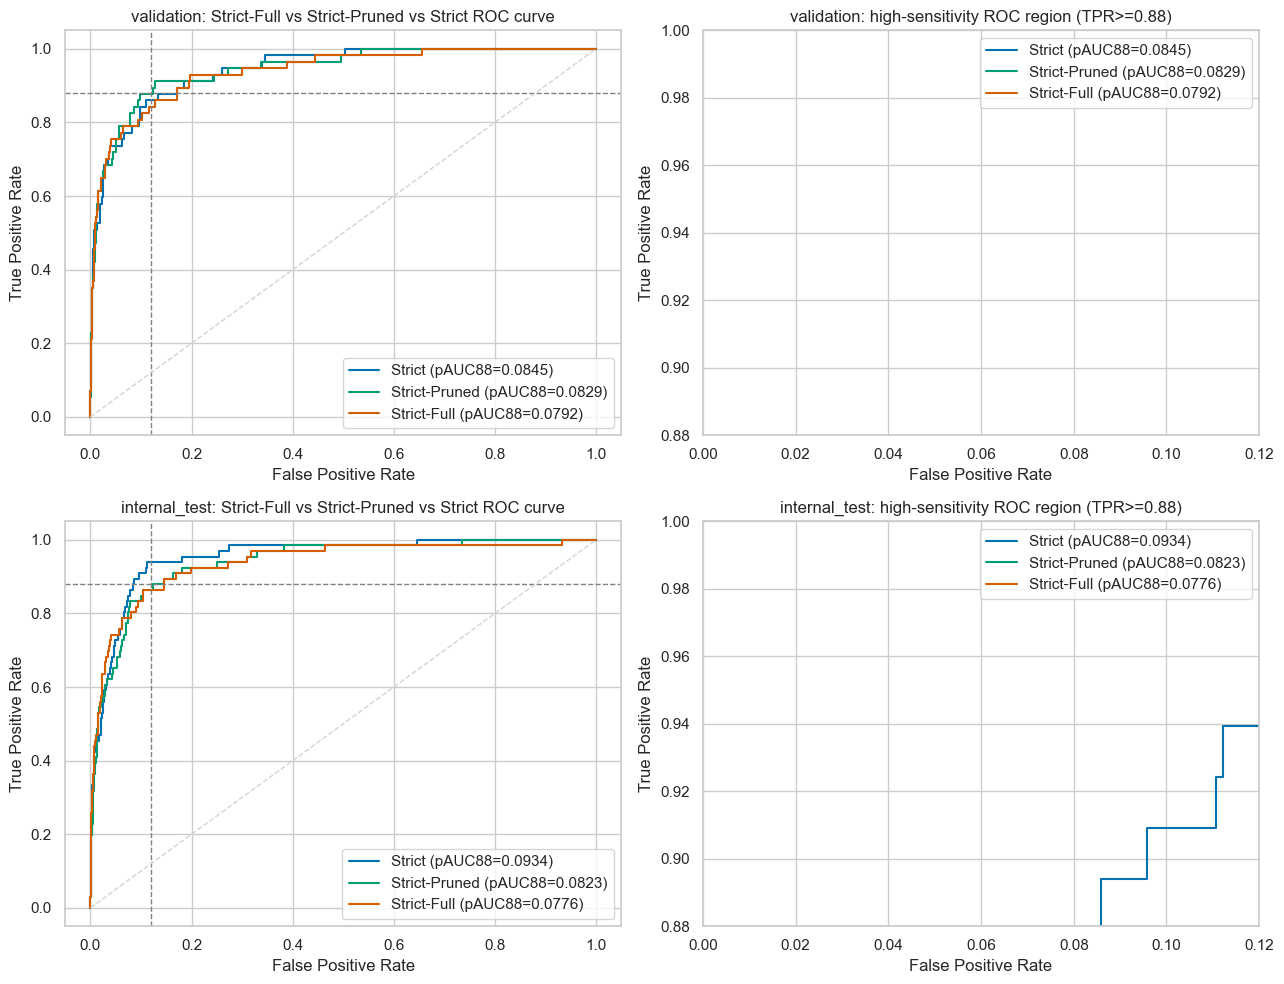

In [5]:
display_cols = [
    'regime_display', 'split', 'pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision',
    'f1', 'recall', 'precision', 'specificity', 'balanced_accuracy',
    'threshold_from_validation_tpr88', 'validation_selected_tpr', 'validation_selected_specificity',
    'best_iteration', 'n_feature_columns'
]
display(metrics_df[display_cols].round(6))

pivot_df = metrics_df.pivot(index='split', columns='regime_display', values=['pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision', 'f1', 'recall', 'precision', 'balanced_accuracy'])
display(pivot_df.round(6))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for idx, split in enumerate(['validation', 'internal_test']):
    ax_roc = axes[idx, 0]
    ax_zoom = axes[idx, 1]
    for regime_name in ['final_strict', 'strict_pruned', 'strict_full']:
        split_pred = predictions_df[(predictions_df['split'] == split) & (predictions_df['regime'] == regime_name)]
        y_true = split_pred['target'].to_numpy()
        y_prob = split_pred['pred_proba'].to_numpy()
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        pauc88 = p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)
        label = f"{DISPLAY_NAME.get(regime_name, regime_name)} (pAUC88={pauc88:.4f})"
        ax_roc.plot(fpr, tpr, label=label, color=DISPLAY_COLOR[regime_name])
        ax_zoom.plot(fpr, tpr, label=label, color=DISPLAY_COLOR[regime_name])

    for ax in [ax_roc, ax_zoom]:
        ax.axhline(PRIMARY_MIN_TPR, linestyle='--', color='gray', linewidth=1)
        ax.axvline(PRIMARY_MAX_FPR, linestyle='--', color='gray', linewidth=1)

    ax_roc.plot([0, 1], [0, 1], linestyle='--', color='lightgray', linewidth=1)
    ax_roc.set_title(f'{split}: Strict-Full vs Strict-Pruned vs Strict ROC curve')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend()

    ax_zoom.set_xlim(0, PRIMARY_MAX_FPR)
    ax_zoom.set_ylim(PRIMARY_MIN_TPR, 1.0)
    ax_zoom.set_title(f'{split}: high-sensitivity ROC region (TPR>=0.88)')
    ax_zoom.set_xlabel('False Positive Rate')
    ax_zoom.set_ylabel('True Positive Rate')
    ax_zoom.legend()

plt.tight_layout()
plt.show()


## 4. Strict-Pruned의 위치 해석

### 목적
코드 셀에서는 `Strict-Pruned`가 `Strict`와 `Strict-Full` 사이에서 어떤 위치를 가지는지 delta 표로 다시 확인합니다.

기본 비교 기준은 `pAUC@TPR>=0.88`입니다.


,comparison,split,delta_pauc_tpr88,delta_pauc_tpr80,delta_average_precision,delta_roc_auc
0,pruned_minus_final,validation,-0.001605,0.000092,-0.013928,0.001024
1,pruned_minus_full,validation,0.003699,0.006702,-0.012146,0.006286
2,pruned_minus_final,internal_test,-0.011127,-0.012813,-0.010580,-0.014564
3,pruned_minus_full,internal_test,0.004703,0.005559,-0.013837,0.001339


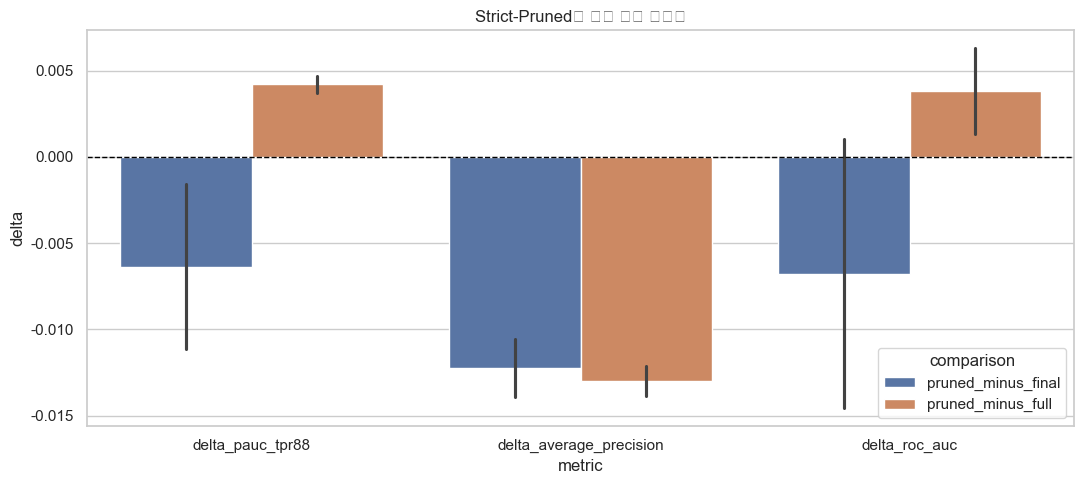

In [6]:
rows = []
for split in ['validation', 'internal_test']:
    final_row = metrics_df[(metrics_df['split'] == split) & (metrics_df['regime'] == 'final_strict')].iloc[0]
    pruned_row = metrics_df[(metrics_df['split'] == split) & (metrics_df['regime'] == 'strict_pruned')].iloc[0]
    full_row = metrics_df[(metrics_df['split'] == split) & (metrics_df['regime'] == 'strict_full')].iloc[0]
    rows.extend([
        {
            'comparison': 'pruned_minus_final',
            'split': split,
            'delta_pauc_tpr88': pruned_row['pauc_tpr88'] - final_row['pauc_tpr88'],
            'delta_pauc_tpr80': pruned_row['pauc_tpr80'] - final_row['pauc_tpr80'],
            'delta_average_precision': pruned_row['average_precision'] - final_row['average_precision'],
            'delta_roc_auc': pruned_row['roc_auc'] - final_row['roc_auc'],
        },
        {
            'comparison': 'pruned_minus_full',
            'split': split,
            'delta_pauc_tpr88': pruned_row['pauc_tpr88'] - full_row['pauc_tpr88'],
            'delta_pauc_tpr80': pruned_row['pauc_tpr80'] - full_row['pauc_tpr80'],
            'delta_average_precision': pruned_row['average_precision'] - full_row['average_precision'],
            'delta_roc_auc': pruned_row['roc_auc'] - full_row['roc_auc'],
        },
    ])

delta_df = pd.DataFrame(rows)
display(delta_df.round(6))

plot_df = delta_df.melt(id_vars=['comparison', 'split'], value_vars=['delta_pauc_tpr88', 'delta_average_precision', 'delta_roc_auc'])
plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x='variable', y='value', hue='comparison')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Strict-Pruned의 상대 성능 변화량')
plt.xlabel('metric')
plt.ylabel('delta')
plt.tight_layout()
plt.show()


### 해석 포인트
1. `pruned_minus_final > 0`이면 pruning이 최종 Strict보다 유리한 것입니다.
2. `pruned_minus_full > 0`이면 pruning이 초기 Strict-Full보다 유리한 것입니다.
3. 가장 먼저 `delta_pauc_tpr88`을 보고, 그 다음 `Average Precision`과 `ROC AUC`를 보조로 봅니다.


## 5. 결론 정리

이 노트북은 세 가지 선택지 중 현재 어떤 세트가 가장 설득력 있는지 판단하기 위한 비교 노트북입니다.

판단 기준 예시:
1. `Strict`가 가장 안정적이면: 최종 메인 세트 유지
2. `Strict-Pruned`가 가장 균형이 좋으면: 다음 실험의 기본 세트로 채택
3. `Strict-Full`이 다시 좋아지면: pruning 방향을 재검토
